In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = []

def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

def to_float(x):
    if x == "-":
        return np.nan

    try:
        return float(x)
    except:
        return np.nan

with open("list.dat", "r") as f:

    for line in f:

        parts = line.split()

        # Ignorar líneas vacías
        if len(parts) < 5:
            continue

        obj_id = parts[0]
        ra = parts[1]
        dec = parts[2]

        # Buscar inicio de columnas numéricas
        first_num = None

        for i in range(3, len(parts)):
            if is_float(parts[i]) or parts[i] == "-":
                first_num = i
                break

        if first_num is None:
            continue

        # Clasificaciones
        class_parts = parts[3:first_num]

        tipo1 = class_parts[0] if len(class_parts) > 0 else None
        tipo2 = class_parts[1] if len(class_parts) > 1 else None

        # Extraer columnas de forma segura
        mag_I = to_float(parts[first_num]) if len(parts) > first_num else np.nan
        mag_V = to_float(parts[first_num + 1]) if len(parts) > first_num + 1 else np.nan
        periodo = to_float(parts[first_num + 2]) if len(parts) > first_num + 2 else np.nan
        amplitud = to_float(parts[first_num + 3]) if len(parts) > first_num + 3 else np.nan

        data.append([
            obj_id,
            ra,
            dec,
            tipo1,
            tipo2,
            mag_I,
            mag_V,
            periodo,
            amplitud
        ])

df = pd.DataFrame(data, columns=[
    "ID",
    "RA",
    "DEC",
    "Tipo",
    "Subtipo",
    "I",
    "V",
    "Periodo",
    "Amplitud"
])

print(df.head())
print(df.shape)

               ID           RA          DEC   Tipo Subtipo       I       V  \
0   LMC563.16.842  05:46:55.53  -66:30:47.6  OTHER    None  18.925  18.981   
1  LMC563.16.1142  05:46:57.17  -66:24:53.9  RRLYR    RRab  19.091  19.745   
2     LMC563.16.8  05:46:57.78  -66:26:43.4    LPV   OSARG  14.662  16.383   
3  LMC563.16.9286  05:46:59.24  -66:18:01.0    ECL    None  18.690  18.808   
4  LMC563.16.2137  05:47:00.94  -66:25:36.0  OTHER    None  19.526  19.529   

      Periodo  Amplitud  
0    1.850940     0.069  
1    0.494447     0.839  
2  369.000000     0.045  
3    0.972667     0.264  
4    0.850470     0.142  
(6789, 9)


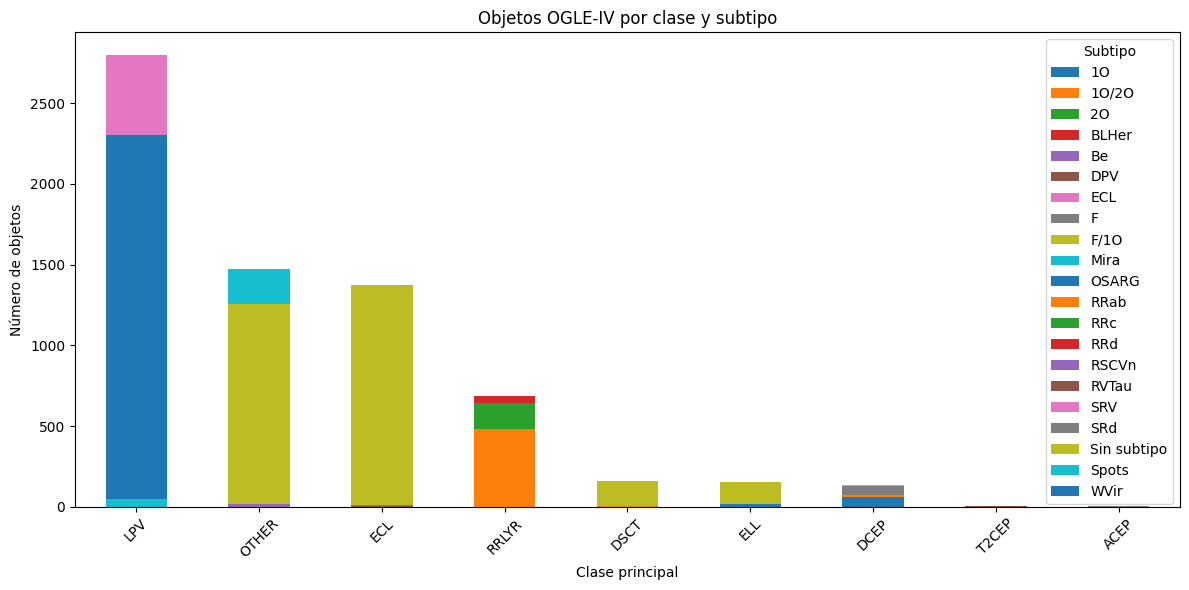

In [ ]:
# Reemplazar subtipos vacíos
df["Subtipo"] = df["Subtipo"].fillna("Sin subtipo")

# Contar objetos por Tipo/Subtipo
counts = (df.groupby(["Tipo", "Subtipo"]).size().unstack(fill_value=0))

# Ordenar por número total
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

# Graficar
ax = counts.plot(kind="bar",stacked=True,figsize=(12,6))

plt.xlabel("Clase principal")
plt.ylabel("Número de objetos")
plt.title("Objetos OGLE-IV por clase y subtipo")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Pulsadores radiales(RRKYR, DSCUTI, DCEPHEID, T2CEPHEID, ANOMALOUSCEPHEID)

En su mayoría, pulsan con menos de 20 días de periodo, aunque algunas lo hacen por más, y las cefeidas clásicas se reportan a más de 100 días. 


Todas tienen varios modos de oscilación, 


Delta Scuti variables are fainter, have shorter pulsation periods, and smaller masses than classical Cepheids, but both groups obey the same period-luminosity relation and it is simply a matter of convention which period defines a boundary between them.


Además, todas son "toboganes" hacia la derecha

LPVARIABLES

OTHER

BINARYECLIPSANTES, ELLIPSOIDALES

Iguales, o similares, porque las binarias eclipsantes tienen un eclipse grande y otro más pequeño, y lo mismo pasa con las elipsoidales. Mientras que con las unas es por el brillo entre una y su compañera, para las elipsoidales es porque una de las dos estrellas hala a la otra y le da una forma de elipse: los polos son más brillantes que el ecuador, y se nota mucho del lado puntiagudo de la estrella.

In [ ]:
#Este código es para separar las clases de las features. YUPIIII

¿Qué features poner?

TEnemos que conocer el periodo. Una vez conocido el periodo(lo da el documento, pero volverlo a buscar con Lomb Scargle?), cómo hacemos para saber que la distribución magnitud contra fase es sinusoidal, diente de sierra, etc? 


Tenemos los datos fotométricos, así que hacer LS no es imposible, y lo haríamos todo en I.


Ahora, para distinguir formas de funciones, podemos buscar distancia en fase entre mínimos y máximos, y máximos y mínimos. la primera es muy corta para dientes de sierra, y la segunda muy larga. Para las otras, es más estándar y su diferencia debería ser cercana a cero.


Además, comparar mínimos y máximos entre sí nos ayuda a las binarias, diría yo. Pero y la precesión de Herzprung no nos jodería ahí?


PERIODO, DELTA MIN-MAX, DELTA MAX-MIN, DELTA MIN-MIN

Va a tocar tener en consideración cómo hacemos para las binarias, porque lomb scargle a un orden no va a funcionar... serían 12, y no va a dar en esta vida. Pero la gran mayoría funciona! podemos encontrar otra manera que no sea MIN-MIN para claificarlas?

La Amplitud cómo nos ayuda?

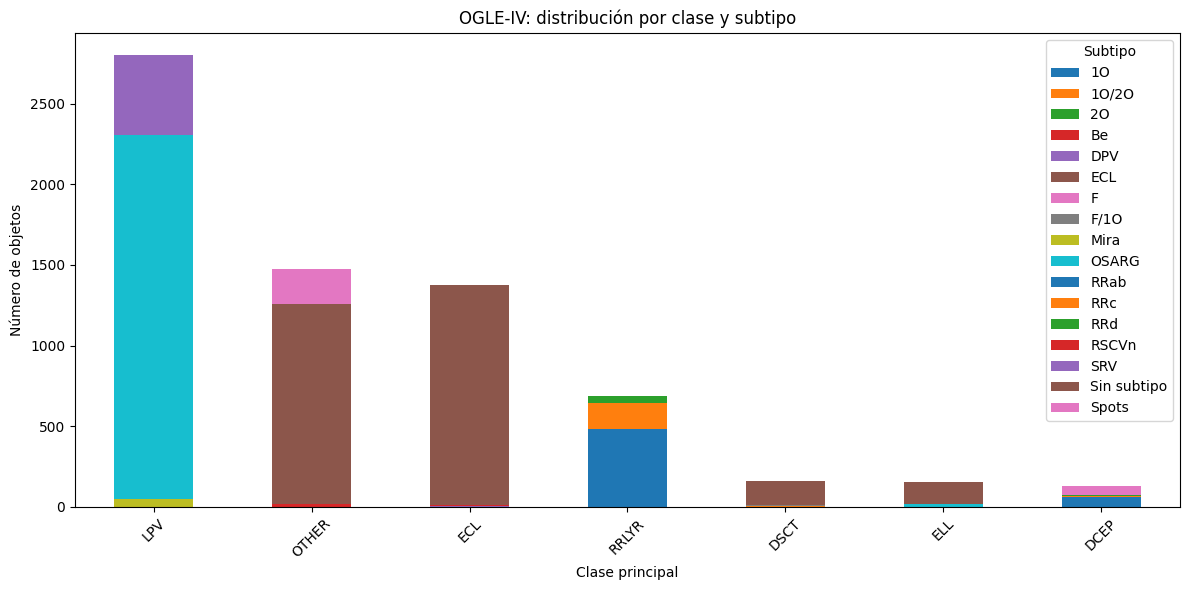

In [14]:
# Eliminar T2CEP y ACEP
df_filtered = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()

# Subtipos vacíos
df_filtered["Subtipo"] = df_filtered["Subtipo"].fillna("Sin subtipo")

# Conteos
counts = (df_filtered.groupby(["Tipo", "Subtipo"]).size().unstack(fill_value=0))

# Ordenar por abundancia
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

# Histograma apilado
ax = counts.plot(kind="bar",stacked=True,figsize=(12,6))

plt.xlabel("Clase principal")
plt.ylabel("Número de objetos")
plt.title("OGLE-IV: distribución por clase y subtipo")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()